# 02 — Hybrid: Adaptive Weighted TV (Jacopo)
**Faithful to Morotti et al. (2025).** Weights computed once from `x̃` via eq.(2.6), fixed. Self-contained; auto-finds shared `.pt`, IPPy operator.

Variants: **TV-Wℓ1** (x̃=early-stopped TV), **Net-Wℓ1** (x̃=UNet), **GT-Wℓ1** (x̃=clean, bound). *Paper uses Chambolle-Pock; here FISTA on smoothed TV.*

In [1]:
# --- Setup (run each session) ---
!pip -q install git+https://github.com/devangelista2/IPPy
!pip -q install PyWavelets scikit-image numpy scipy matplotlib pandas

  Preparing metadata (setup.py) ... done


In [2]:
# ================= PREAMBLE (self-contained) =================
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
import os, glob, torch, numpy as np
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio as _psnr, structural_similarity as _ssim
from IPPy import operators, utilities

# ---- auto-find the shared .pt folder (no need to type the path) ----
hits = glob.glob("/content/drive/MyDrive/**/noise_*.pt", recursive=True)
assert hits, "No noise_*.pt found. Make sure Shivam's retina_processed shortcut is under MyDrive."
PROCESSED = Path(os.path.dirname(os.path.dirname(hits[0])))
print("PROCESSED =", PROCESSED, "| splits:", os.listdir(PROCESSED))

IMG_SIZE = 256
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

# SAME blur operator that created the degraded data
K = operators.Blurring(img_shape=(IMG_SIZE,IMG_SIZE), kernel_type="motion",
                       kernel_size=9, motion_angle=45)
class IPPyForward:
    @torch.no_grad()
    def A(self, x):  return K(torch.from_numpy(np.ascontiguousarray(x)).float()[None,None])[0,0].detach().numpy()
    @torch.no_grad()
    def AT(self, x): return K.T(torch.from_numpy(np.ascontiguousarray(x)).float()[None,None])[0,0].detach().numpy()
fw = IPPyForward()   # ||K^T K|| ~ 1 => FISTA step L=1 valid

def psnr(g,p): return float(_psnr(g,p,data_range=1.0))
def ssim(g,p): return float(_ssim(g,p,data_range=1.0))

def noise_file_name(nl): return f"noise_{str(nl).replace('.', '_')}.pt"
def load_pt(split, nl):
    d = torch.load(PROCESSED/split/noise_file_name(nl), map_location="cpu")
    clean    = d["clean"].numpy()[:,0].astype(np.float32)
    degraded = d["degraded"].numpy()[:,0].astype(np.float32)
    return clean, degraded

cl, dg = load_pt("test", 0.01)
print("test set:", cl.shape[0], "images | PSNR(img0):", round(psnr(cl[0],dg[0]),2))
# ============================ END PREAMBLE ============================

Mounted at /content/drive
PROCESSED = /content/drive/MyDrive/GroupF/retina_processed | splits: ['train', 'validation', 'test']
test set: 600 images | PSNR(img0): 34.51


### Method (faithful weighted-TV)

In [3]:
def _grad(z):
    gx=np.zeros_like(z); gy=np.zeros_like(z)
    gx[:,:-1]=z[:,1:]-z[:,:-1]; gy[:-1,:]=z[1:,:]-z[:-1,:]; return gx,gy
def _div(px,py):
    dx=np.zeros_like(px); dy=np.zeros_like(py)
    dx[:,1:]=px[:,1:]-px[:,:-1]; dx[:,0]=px[:,0]
    dy[1:,:]=py[1:,:]-py[:-1,:]; dy[0,:]=py[0,:]; return dx+dy
def tv_fista(y, fw, lam, n_iter=300, eps=1e-2, w=None):
    if w is None: w=np.ones_like(y)
    x=np.clip(fw.AT(y),0,1); z=x.copy(); t=1.; L=1.0+lam*8.0/eps
    for _ in range(n_iter):
        gx,gy=_grad(z); mag=np.sqrt(gx*gx+gy*gy+eps*eps)
        g=fw.AT(fw.A(z)-y)+lam*(-_div(w*gx/mag, w*gy/mag))
        xn=np.clip(z-g/L,0,1); tn=(1+np.sqrt(1+4*t*t))/2
        z=xn+((t-1)/tn)*(xn-x); x,t=xn,tn
    return x
def weights_from(xtilde, p=0.3, eta=2e-2):
    gx,gy=_grad(xtilde); mag=np.sqrt(gx*gx+gy*gy)
    return (eta/np.sqrt(eta**2 + mag**2))**(1-p)
def tv_wl1(y, fw, lam, p=0.3, eta=2e-2, n_iter=300, lam_recon=0.01, n_recon=40):
    xtilde = tv_fista(y, fw, lam_recon, n_recon)
    return tv_fista(y, fw, lam, n_iter, w=weights_from(xtilde, p, eta))
def gt_wl1(y, fw, lam, x_gt, p=0.3, eta=2e-2, n_iter=300):
    return tv_fista(y, fw, lam, n_iter, w=weights_from(x_gt, p, eta))
def net_wl1(y, fw, lam, net_reconstruct, p=0.3, eta=2e-2, n_iter=300):
    return tv_fista(y, fw, lam, n_iter, w=weights_from(net_reconstruct(y), p, eta))

### Scoring + output path

In [4]:
import pandas as pd
def _scores_pt(fn, split, sigma, lam, n=None):
    clean, degraded = load_pt(split, sigma)
    if n: clean, degraded = clean[:n], degraded[:n]
    ps=[]; ss=[]
    for x, y in zip(clean, degraded):
        r = fn(y, fw, lam)
        ps.append(psnr(x,r)); ss.append(ssim(x,r))
    return np.mean(ps), np.std(ps), np.mean(ss), np.std(ss)

OUT_METRICS = str(PROCESSED.parent / "GroupF_Output" / "metrics")
os.makedirs(OUT_METRICS, exist_ok=True)
print("metrics ->", OUT_METRICS)

metrics -> /content/drive/MyDrive/GroupF/GroupF_Output/metrics


### Preview

TV-Wl1 lam=0.005: 44.16/0.974
TV-Wl1 lam=0.01: 43.36/0.969
TV-Wl1 lam=0.02: 42.54/0.964
TV-Wl1 lam=0.05: 41.39/0.956
best lambda: 0.005


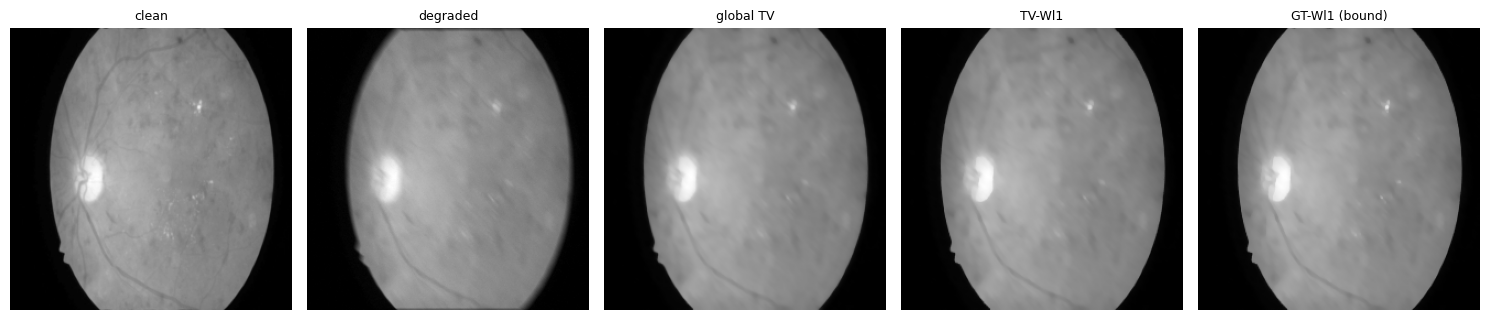

In [5]:
import matplotlib.pyplot as plt
cl, dg = load_pt("test", 0.01); x, y = cl[0], dg[0]
g  = tv_fista(y,fw,0.005,300)
rows=[]
for lam in [0.005,0.01,0.02,0.05]:
    r=tv_wl1(y,fw,lam); rows.append((lam,psnr(x,r),ssim(x,r)))
    print(f"TV-Wl1 lam={lam}: {psnr(x,r):.2f}/{ssim(x,r):.3f}")
best=max(rows,key=lambda t:t[1]); print("best lambda:",best[0])
tw=tv_wl1(y,fw,best[0]); gw=gt_wl1(y,fw,best[0],x)
ims=[x,y,g,tw,gw]; ts=["clean","degraded","global TV","TV-Wl1","GT-Wl1 (bound)"]
fig,ax=plt.subplots(1,5,figsize=(15,3.4))
for a,im,tt in zip(ax,ims,ts): a.imshow(im,cmap="gray"); a.set_title(tt,fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

### Tune λ on validation (TV-Wℓ1)

In [6]:
LAMBDAS=[0.005,0.01,0.02,0.05]; N_TUNE=40
tune_rows=[]
for sigma in NOISE_LEVELS:
    bp=(None,-1); bs=(None,-1)
    for lam in LAMBDAS:
        pm,_,sm,_=_scores_pt(tv_wl1,"validation",sigma,lam,n=N_TUNE)
        tune_rows.append({"sigma":sigma,"lambda":lam,"psnr":pm,"ssim":sm})
        if pm>bp[1]: bp=(lam,pm)
        if sm>bs[1]: bs=(lam,sm)
    print(f"sigma={sigma}: best-PSNR lam={bp[0]} ({bp[1]:.2f}) | best-SSIM lam={bs[0]} ({bs[1]:.3f})")
tune_df=pd.DataFrame(tune_rows); tune_df.to_csv(f"{OUT_METRICS}/awtv_tuning.csv",index=False)
chosen={s: float(tune_df[tune_df.sigma==s].sort_values("ssim").iloc[-1]["lambda"]) for s in NOISE_LEVELS}
print("chosen lambdas (SSIM):", chosen)

sigma=0.005: best-PSNR lam=0.005 (41.87) | best-SSIM lam=0.005 (0.963)
sigma=0.01: best-PSNR lam=0.005 (41.73) | best-SSIM lam=0.005 (0.962)
sigma=0.05: best-PSNR lam=0.01 (39.05) | best-SSIM lam=0.01 (0.918)
sigma=0.1: best-PSNR lam=0.05 (36.52) | best-SSIM lam=0.05 (0.853)
chosen lambdas (SSIM): {0.005: 0.005, 0.01: 0.005, 0.05: 0.01, 0.1: 0.05}


### Full evaluation on test (resume-safe)

In [7]:
final=[]
for sigma in NOISE_LEVELS:
    out=f"{OUT_METRICS}/awtv_sigma{sigma}.csv"
    if os.path.exists(out):
        print(f"sigma={sigma} già salvato, salto"); final.append(pd.read_csv(out).iloc[0].to_dict()); continue
    lam=float(chosen[sigma])
    pm,psd,sm,ssd=_scores_pt(tv_wl1,"test",sigma,lam)
    row={"method":"awtv","sigma":sigma,"lambda":lam,"psnr_mean":pm,"psnr_std":psd,"ssim_mean":sm,"ssim_std":ssd}
    final.append(row); pd.DataFrame([row]).to_csv(out,index=False)
    print(f"sigma={sigma}  PSNR {pm:.2f}±{psd:.2f}  SSIM {sm:.3f}±{ssd:.3f}  (lam={lam})")
pd.DataFrame(final).to_csv(f"{OUT_METRICS}/awtv_all.csv",index=False); print("saved awtv_all.csv")

sigma=0.005  PSNR 42.07±3.72  SSIM 0.964±0.022  (lam=0.005)
sigma=0.01  PSNR 41.93±3.67  SSIM 0.962±0.022  (lam=0.005)
sigma=0.05  PSNR 39.27±3.32  SSIM 0.917±0.044  (lam=0.01)
sigma=0.1  PSNR 36.69±3.01  SSIM 0.848±0.089  (lam=0.05)
saved awtv_all.csv
